<a href="https://colab.research.google.com/github/rmani10063/metadrive-insight/blob/main/Copy_of_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving FINAL_DATASET (6).zip to FINAL_DATASET (6).zip


In [ ]:
import zipfile

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("✅ Dataset Extracted")

✅ Dataset Extracted


In [ ]:
import os
print(os.listdir("/content/data"))

['CRACK', 'PINHOLE', 'GOOD']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/data",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/content/data",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 1800 images belonging to 3 classes.
Found 450 images belonging to 3 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.3478 - loss: 1.2179 - val_accuracy: 0.3622 - val_loss: 1.0952
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.3583 - loss: 1.0971 - val_accuracy: 0.3333 - val_loss: 1.2279
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.3583 - loss: 1.0952 - val_accuracy: 0.3333 - val_loss: 1.1048
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.3539 - loss: 1.0932 - val_accuracy: 0.4022 - val_loss: 1.0919
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.4222 - loss: 1.0858 - val_accuracy: 0.4800 - val_loss: 1.0291
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.3850 - loss: 1.0866 - val_accuracy: 0.3844 - val_loss: 1.0945
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.4389 - loss: 1.0680 - val_accuracy: 0.4867 - val_loss: 1.0731
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.3844 - loss: 1.0795 - val_accu

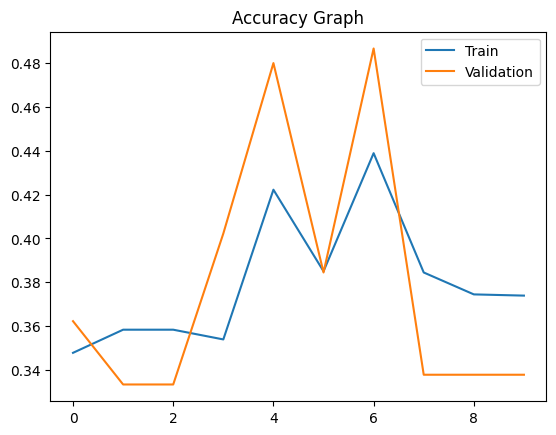

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 2.png to 2 (1).png


In [ ]:
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
pred_index = np.argmax(prediction)
label = class_names[pred_index]
confidence = prediction[0][pred_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [ ]:
if label == "good":
    print(f"✅ NO DEFECT (GOOD) - {confidence*100:.2f}%")

elif label == "crack":
    print(f"❌ DEFECT: CRACK - {confidence*100:.2f}%")

elif label == "pinhole":
    print(f"❌ DEFECT: PINHOLE - {confidence*100:.2f}%")

In [ ]:
epochs = 15

In [ ]:
history = model.fit(train_data, validation_data=val_data, epochs=epochs)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.3833 - loss: 1.0666 - val_accuracy: 0.3978 - val_loss: 0.9744
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.4139 - loss: 1.0826 - val_accuracy: 0.3333 - val_loss: 1.0994
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.3700 - loss: 1.0825 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.3689 - loss: 1.0776 - val_accuracy: 0.3378 - val_loss: 1.0967
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.3739 - loss: 1.0795 - val_accuracy: 0.3378 - val_loss: 1.0977
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.3850 - loss: 1.0743 - val_accuracy: 0.3378 - val_loss: 1.0963
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.3911 - loss: 1.0697 - val_accuracy: 0.3378 - val_loss: 1.0942
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.3733 - loss: 1.0605 - val_accu

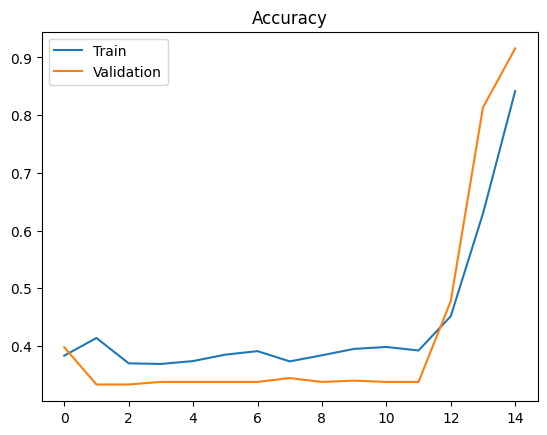

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 32.png to 32.png


In [ ]:
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
pred_index = np.argmax(prediction)
label = class_names[pred_index]
confidence = prediction[0][pred_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


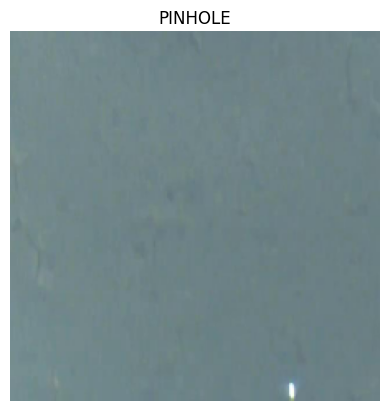

In [ ]:
plt.imshow(img)
plt.title(label)
plt.axis("off")
plt.show()